# Study 295 -- Stablecoin-Supply
## For the quants: lagged vs contemporaneous HAC regressions, bootstrap CI, sub-period decay

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stablecoin_supply import data, strategy as st

CACHE_PATH = data.BTC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    btc = data.fetch_btc_monthly(fetch=False, cache_path=CACHE_PATH)
    panel = data.build_real_panel(btc)
    rets = st.timed_returns(panel, window=1, threshold=0.0, one_way_bps=0.0)
    excess = (rets["timed"] - rets["btc"]).dropna()
    print(f"Real panel loaded: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Long {int(rets['weight'].sum())} / flat {int((rets['weight']==0).sum())} months")
else:
    btc = panel = rets = excess = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 101 months  2018-01-31 -> 2026-05-31
Long 77 / flat 24 months


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 101, 'months_long': 77, 'months_flat': 24, 'btc_ann': 41.2, 'btc_sr': 0.61, 'btc_t': 1.51, 'btc_dd': -73.0, 'timed_ann': 49.5, 'timed_sr': 0.85, 'timed_t': 2.09, 'timed_dd': -50.0, 'exc_ann': 8.3, 'exc_t': 0.72, 'exc_hit': 0.129, 'exc_ci_lo': -0.423, 'exc_ci_hi': 0.899, 'exc_frac_neg': 0.213, 'lag1_beta': 0.0417, 'lag1_t': 1.59, 'lag1_r2': 0.047, 'lag1_corr': 0.217, 'lag1_n': 99, 'lag0_beta': 0.0532, 'lag0_t': 2.15, 'lag0_r2': 0.077, 'lag0_corr': 0.277, 'lag0_n': 100, 'sub1_label': '2018-2020', 'sub1_beta': 0.0984, 'sub1_t': 3.05, 'sub1_n': 34, 'sub2_label': '2021-2022', 'sub2_beta': 0.0308, 'sub2_t': 0.75, 'sub2_n': 22, 'sub3_label': '2023-2026', 'sub3_beta': 0.0002, 'sub3_t': 0.01, 'sub3_n': 39, 'turnover_pct': 8.9, 'net10_ann': 49.4, 'net10_t': 2.09, 'net25_ann': 49.3, 'net25_t': 2.08, 'net50_ann': 49.0, 'net50_t': 2.07, 'syn_null_t': -0.13, 'syn_live_t': 3.48, 'syn_live_beta': 0.0386, 'btc_fp': '41dff5f08708', 'panel_fp': 'ae8e27f23d83'}


## Positive control: the engine recovers a planted dry-powder premium

In [3]:
# Synthetic positive control: planted premium=0.04 -> lagged slope t > 2 strongly
df_live, truth = data.synthetic_panel(n_months=200, premium=0.04, seed=295)
r_live = st.predictive_regression(df_live, window=1, lag=1)
print(f"Synthetic positive control (premium=0.04):")
print(f"  Lagged slope = {r_live['beta']:+.4f}  HAC t = {r_live['tstat']:+.2f}  n = {r_live['n']}")

# Null control: premium=0.0
df_null, _ = data.synthetic_panel(n_months=200, premium=0.0, seed=295)
r_null = st.predictive_regression(df_null, window=1, lag=1)
print(f"\nNull control (premium=0.0):")
print(f"  Lagged slope = {r_null['beta']:+.4f}  HAC t = {r_null['tstat']:+.2f}  n = {r_null['n']}")
print("  -> Engine reads strong on planted signal, ~zero on the null.")


Synthetic positive control (premium=0.04):
  Lagged slope = +0.0386  HAC t = +3.48  n = 198

Null control (premium=0.0):
  Lagged slope = -0.0014  HAC t = -0.13  n = 198
  -> Engine reads strong on planted signal, ~zero on the null.


## Primary specification: supply-timed vs buy-and-hold (HAC + bootstrap)

In [4]:
if HAVE_REAL:
    s_btc   = st.summarize(rets["btc"])
    s_timed = st.summarize(rets["timed"])
    s_exc   = st.summarize(excess)
    print("=== Supply-timed (long when supply grew last month) vs buy-and-hold BTC ===")
    print(f"Months: {len(rets)}  (long {int(rets['weight'].sum())} / flat {int((rets['weight']==0).sum())})")
    print(f"BTC   : {s_btc['mean']*12*100:+.1f}%/yr  SR(ann)={s_btc['sharpe']*12**0.5:+.2f}  HAC t={s_btc['tstat']:+.2f}  maxDD={s_btc['max_drawdown']*100:.0f}%")
    print(f"TIMED : {s_timed['mean']*12*100:+.1f}%/yr  SR(ann)={s_timed['sharpe']*12**0.5:+.2f}  HAC t={s_timed['tstat']:+.2f}  maxDD={s_timed['max_drawdown']*100:.0f}%")
    print(f"EXCESS: {s_exc['mean']*12*100:+.1f}%/yr  HAC t={s_exc['tstat']:+.2f}  hit={s_exc['hit_rate']:.3f}")
    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(excess, n_boot=2000, periods_per_year=12, seed=295)
        print(f"\nExcess Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% negative)")
    except ImportError:
        print(f"\n[quantlab.stats unavailable -- frozen CI: [{R['exc_ci_lo']:+.3f}, {R['exc_ci_hi']:+.3f}]]")
else:
    print(f"Frozen: BTC {R['btc_ann']:+.1f}%/yr (t={R['btc_t']:+.2f}), timed {R['timed_ann']:+.1f}%/yr (t={R['timed_t']:+.2f})")
    print(f"Excess (timed - BTC): {R['exc_ann']:+.1f}%/yr  HAC t = +{R['exc_t']:.2f}  hit={R['exc_hit']:.3f}")
    print(f"Excess Sharpe 95% CI: [{R['exc_ci_lo']:+.3f}, {R['exc_ci_hi']:+.3f}]  ({R['exc_frac_neg']*100:.0f}% negative)")
print("\nThe timed series beats BTC on paper but the EXCESS is not significant -- it is beta timing.")


=== Supply-timed (long when supply grew last month) vs buy-and-hold BTC ===
Months: 101  (long 77 / flat 24)
BTC   : +41.2%/yr  SR(ann)=+0.61  HAC t=+1.51  maxDD=-73%
TIMED : +49.5%/yr  SR(ann)=+0.85  HAC t=+2.09  maxDD=-50%
EXCESS: +8.3%/yr  HAC t=+0.72  hit=0.129



Excess Sharpe 95% CI: [-0.423, +0.899]  (21% negative)

The timed series beats BTC on paper but the EXCESS is not significant -- it is beta timing.


## Reflexivity: lagged (tradable) vs contemporaneous (not tradable)

LAGGED (t+1, tradable)          : beta=+0.0417  HAC t=+1.59  R2=0.0470  corr=+0.217  n=99
CONTEMPORANEOUS (t, NOT tradable): beta=+0.0532  HAC t=+2.15  R2=0.0767  corr=+0.277  n=100


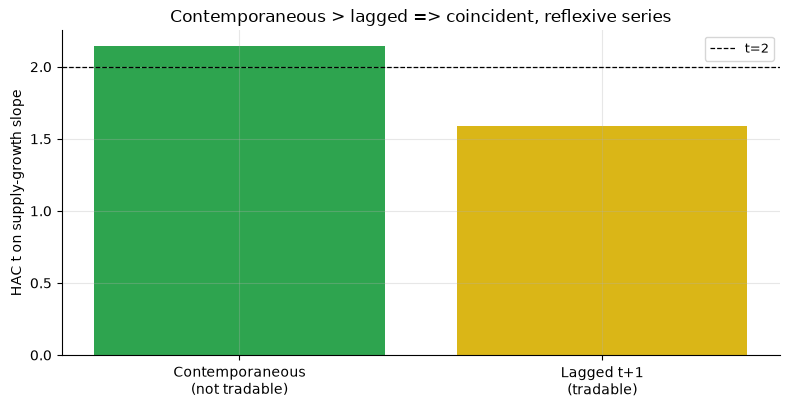

Significant link is contemporaneous (non-tradable); tradable lagged link clears no bar.


In [5]:
if HAVE_REAL:
    r1 = st.predictive_regression(panel, window=1, lag=1)
    r0 = st.predictive_regression(panel, window=1, lag=0)
    print(f"LAGGED (t+1, tradable)          : beta={r1['beta']:+.4f}  HAC t={r1['tstat']:+.2f}  R2={r1['r2']:.4f}  corr={r1['corr']:+.3f}  n={r1['n']}")
    print(f"CONTEMPORANEOUS (t, NOT tradable): beta={r0['beta']:+.4f}  HAC t={r0['tstat']:+.2f}  R2={r0['r2']:.4f}  corr={r0['corr']:+.3f}  n={r0['n']}")
    t_lag, t_con = r1["tstat"], r0["tstat"]
else:
    print(f"Frozen LAGGED          : beta={R['lag1_beta']:+.4f}  HAC t=+{R['lag1_t']:.2f}  R2={R['lag1_r2']:.3f}  n={R['lag1_n']}")
    print(f"Frozen CONTEMPORANEOUS : beta={R['lag0_beta']:+.4f}  HAC t=+{R['lag0_t']:.2f}  R2={R['lag0_r2']:.3f}  n={R['lag0_n']}")
    t_lag, t_con = R["lag1_t"], R["lag0_t"]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ["Contemporaneous\n(not tradable)", "Lagged t+1\n(tradable)"]
tv = [t_con, t_lag]
ax.bar(bars, tv, color=[GREEN if t >= 2 else AMBER for t in tv])
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2")
ax.set_ylabel("HAC t on supply-growth slope")
ax.set_title("Contemporaneous > lagged => coincident, reflexive series")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Significant link is contemporaneous (non-tradable); tradable lagged link clears no bar.")


## Sub-period decay of the lagged (tradable) regression

  2018-2020: beta=+0.0984  HAC t=+3.05  n=34
  2021-2022: beta=+0.0308  HAC t=+0.75  n=22
  2023-2026: beta=+0.0002  HAC t=+0.01  n=39


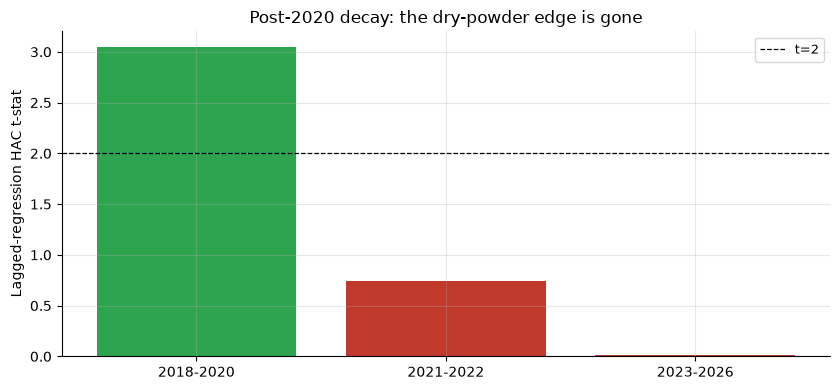

The lagged predictive power was a 2018-2020 artefact; it has decayed to t~0.


In [6]:
if HAVE_REAL:
    sub_stats = []
    for label, a, b in [("2018-2020","2018","2020"), ("2021-2022","2021","2022"), ("2023-2026","2023","2026")]:
        r = st.predictive_regression(panel[a:b], window=1, lag=1)
        sub_stats.append((label, r["tstat"], r["n"]))
        print(f"  {label}: beta={r['beta']:+.4f}  HAC t={r['tstat']:+.2f}  n={r['n']}")
else:
    sub_stats = [(R["sub1_label"], R["sub1_t"], R["sub1_n"]),
                 (R["sub2_label"], R["sub2_t"], R["sub2_n"]),
                 (R["sub3_label"], R["sub3_t"], R["sub3_n"])]
    for label, t, n in sub_stats:
        print(f"  {label}: HAC t={t:+.2f}  n={n}")

fig, ax = plt.subplots(figsize=(8.5, 4))
labels = [s[0] for s in sub_stats]; tvals = [s[1] for s in sub_stats]
ax.bar(labels, tvals, color=[GREEN if t >= 2 else AMBER if t >= 1 else RED for t in tvals])
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2")
ax.set_ylabel("Lagged-regression HAC t-stat")
ax.set_title("Post-2020 decay: the dry-powder edge is gone")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("The lagged predictive power was a 2018-2020 artefact; it has decayed to t~0.")


## Turnover and cost drag -- not the binding constraint

In [7]:
if HAVE_REAL:
    to = st.turnover(panel)
    print(f"Avg monthly switch rate: {to:.2%}")
    for bps in (10, 25, 50):
        rn = st.timed_returns(panel, one_way_bps=bps)
        sn = st.summarize(rn["timed_net"])
        print(f"  Net timed @{bps}bps one-way: {sn['mean']*12*100:+.1f}%/yr  HAC t={sn['tstat']:+.2f}")
else:
    print(f"Frozen: switch rate {R['turnover_pct']:.1f}%/mo")
    print(f"  Net @10bps: {R['net10_ann']:+.1f}%/yr  t={R['net10_t']:+.2f}")
    print(f"  Net @25bps: {R['net25_ann']:+.1f}%/yr  t={R['net25_t']:+.2f}")
    print(f"  Net @50bps: {R['net50_ann']:+.1f}%/yr  t={R['net50_t']:+.2f}")
print("\nCosts barely dent the timed series (supply grows most months -> few switches).")
print("The binding constraint is the ABSENCE of a tradable signal, not transaction cost.")


Avg monthly switch rate: 8.91%
  Net timed @10bps one-way: +49.4%/yr  HAC t=+2.09
  Net timed @25bps one-way: +49.3%/yr  HAC t=+2.08
  Net timed @50bps one-way: +49.0%/yr  HAC t=+2.07

Costs barely dent the timed series (supply grows most months -> few switches).
The binding constraint is the ABSENCE of a tradable signal, not transaction cost.


## Verdict

In [8]:
print("=== Study 295 -- Stablecoin-Supply ===")
print()
print(f"Signal: WEAK")
print(f"  Tradable lagged slope HAC t = +{R['lag1_t']:.2f}  (< 2 inference bar)")
print(f"  Significant link is CONTEMPORANEOUS (t = +{R['lag0_t']:.2f}) = reflexive, non-tradable")
print(f"  Decayed: t = +{R['sub1_t']:.2f} (2018-20) -> +{R['sub3_t']:.2f} (2023-26)")
print(f"  Synthetic positive control confirms the engine works (planted t = +{R['syn_live_t']:.2f})")
print()
print(f"Tradability: MIRAGE")
print(f"  Timed beats BTC on paper (SR {R['timed_sr']:.2f} vs {R['btc_sr']:.2f}) but")
print(f"  EXCESS over buy-and-hold HAC t = +{R['exc_t']:.2f}, bootstrap CI [{R['exc_ci_lo']:+.2f}, {R['exc_ci_hi']:+.2f}] straddles zero")
print(f"  It is BTC beta-timing in a single bull market, not alpha")
print()
print("Reflexivity / data caveat: NAMED -- coincident series; curated public-aggregate supply;")
print("  single-survivor BTC spot (price-only == total-return); strict one-month lag.")
print()
print("Bottom line: Weak/Mirage -- a reflexive, coincident series masquerading as a leading signal.")


=== Study 295 -- Stablecoin-Supply ===

Signal: WEAK
  Tradable lagged slope HAC t = +1.59  (< 2 inference bar)
  Significant link is CONTEMPORANEOUS (t = +2.15) = reflexive, non-tradable
  Decayed: t = +3.05 (2018-20) -> +0.01 (2023-26)
  Synthetic positive control confirms the engine works (planted t = +3.48)

Tradability: MIRAGE
  Timed beats BTC on paper (SR 0.85 vs 0.61) but
  EXCESS over buy-and-hold HAC t = +0.72, bootstrap CI [-0.42, +0.90] straddles zero
  It is BTC beta-timing in a single bull market, not alpha

Reflexivity / data caveat: NAMED -- coincident series; curated public-aggregate supply;
  single-survivor BTC spot (price-only == total-return); strict one-month lag.

Bottom line: Weak/Mirage -- a reflexive, coincident series masquerading as a leading signal.
